<a href="https://colab.research.google.com/github/LuanLindolfo/diabetes_prediction/blob/main/proj2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Resources

# 1. IMPORTAÇÃO DAS BIBLIOTECAS

In [1]:
import os # Para interagir com o sistema operacional (caminhos de arquivo)
import kagglehub # Para baixar datasets diretamente do Kaggle
import pandas as pd # Para manipulação e análise de dados tabulares (DataFrames)
import numpy as np # Para operações numéricas e arrays multidimensionais
import matplotlib.pyplot as plt # Para criar visualizações estáticas e interativas
import pickle # Para serializar e desserializar objetos Python (salvar e carregar modelos)

# Pré-processamento e Métricas do Scikit-learn
from sklearn.model_selection import train_test_split # Para dividir os dados em conjuntos de treino e teste
from sklearn.preprocessing import StandardScaler # Para padronizar os dados (escalar para média 0 e desvio padrão 1)
from sklearn.metrics import accuracy_score, recall_score, precision_score, classification_report, ConfusionMatrixDisplay # Para avaliar o desempenho do modelo (acurácia, recall, precisão) e exibir matriz de confusão

# Algoritmos de Machine Learning do Scikit-learn
from sklearn.naive_bayes import GaussianNB # Classificador Naïve Bayes Gaussiano
from sklearn.linear_model import LogisticRegression # Algoritmo de Regressão Logística
from sklearn.neighbors import KNeighborsClassifier # Algoritmo K-Nearest Neighbors (KNN)
from sklearn.tree import DecisionTreeClassifier # Algoritmo de Árvore de Decisão
from sklearn.ensemble import RandomForestClassifier # Algoritmo Random Forest (conjunto de árvores de decisão)
from sklearn.svm import SVC # Máquina de Vetores de Suporte (Support Vector Machine)

# 2. CARREGAMENTO E PRÉ-PROCESSAMENTO

In [2]:
# ==============================================================================
# 2. CARREGAMENTO E PRÉ-PROCESSAMENTO (ATUALIZADO)
# ==============================================================================

print("⏳ Baixando o dataset diretamente do Kaggle...")
caminho_pasta = kagglehub.dataset_download("alexteboul/diabetes-health-indicators-dataset")
print(f"✅ Pasta baixada em: {caminho_pasta}")

caminho_arquivo = os.path.join(caminho_pasta, "diabetes_binary_5050split_health_indicators_BRFSS2015.csv")

print("\n⚙️ Carregando e preparando os dados no Pandas...")
df = pd.read_csv(caminho_arquivo)

# 🛑 NOVO: FILTRANDO APENAS AS COLUNAS MAIS IMPORTANTES 🛑
colunas_selecionadas = ['Diabetes_binary', 'HighBP', 'HighChol', 'BMI', 'Age']
df = df[colunas_selecionadas]

# Separação entre Previsores (X) e Classe Alvo (Y)
X = df.drop(columns=['Diabetes_binary']).values
Y = df['Diabetes_binary'].values

# Padronização dos dados
scaler = StandardScaler()
X_padronizado = scaler.fit_transform(X)

# Divisão dos dados em conjuntos de Treino (80%) e Teste (20%)
X_treino, X_teste, Y_treino, Y_teste = train_test_split(
    X_padronizado, Y, test_size=0.20, random_state=42
)

print(f"Registros para treinamento: {X_treino.shape[0]}")
print(f"Registros para teste: {X_teste.shape[0]}")

⏳ Baixando o dataset diretamente do Kaggle...
Using Colab cache for faster access to the 'diabetes-health-indicators-dataset' dataset.
✅ Pasta baixada em: /kaggle/input/diabetes-health-indicators-dataset

⚙️ Carregando e preparando os dados no Pandas...
Registros para treinamento: 56553
Registros para teste: 14139


# 3. TREINAMENTO E AVALIAÇÃO DOS MODELOS

In [3]:
print("\nIniciando treinamento e avaliação dos modelos...\n")

# Dicionário que armazena instâncias de diferentes modelos de Machine Learning a serem testados
modelos = {
    "Naïve Bayes": GaussianNB(),
    "Regressão Logística": LogisticRegression(max_iter=1000, random_state=42), # max_iter para convergência
    "KNN": KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2), # 5 vizinhos, distância euclidiana
    "Árvore de Decisão": DecisionTreeClassifier(criterion='entropy', random_state=42), # Critério de entropia
    "Random Forest": RandomForestClassifier(n_estimators=100, criterion='entropy', random_state=42), # 100 árvores, critério de entropia
    "SVM (Linear)": SVC(kernel='linear', random_state=42) # SVM com kernel linear
}

resultados = [] # Lista para armazenar as métricas de cada modelo
melhor_recall = 0 # Variável para acompanhar o maior recall encontrado
nome_melhor_modelo = "" # Nome do modelo com o melhor recall
modelo_vencedor = None # Objeto do modelo com o melhor recall

# Loop para treinar e testar todos os modelos definidos no dicionário 'modelos'
for nome, modelo in modelos.items():
    # Treinamento do modelo com os dados de treino
    modelo.fit(X_treino, Y_treino)

    # Realiza previsões no conjunto de teste
    previsoes = modelo.predict(X_teste)

    # Coleta de Métricas de desempenho
    acuracia = accuracy_score(Y_teste, previsoes)
    recall = recall_score(Y_teste, previsoes) # Calcula o Recall (principal métrica para este problema de saúde)
    precisao = precision_score(Y_teste, previsoes) # Calcula a Precisão

    # Adiciona os resultados do modelo atual à lista de resultados
    resultados.append({
        "Modelo": nome,
        "Acurácia": round(acuracia, 4),
        "Recall": round(recall, 4),
        "Precisão": round(precisao, 4)
    })

    # Verifica se o recall do modelo atual é o melhor até agora
    if recall > melhor_recall:
        melhor_recall = recall # Atualiza o melhor recall
        nome_melhor_modelo = nome # Atualiza o nome do melhor modelo
        modelo_vencedor = modelo # Armazena o objeto do melhor modelo


Iniciando treinamento e avaliação dos modelos...



# 4. EXIBIÇÃO DOS RESULTADOS

🏆 RANKING DOS MODELOS (Ordenado por Recall):


,Modelo,Acurácia,Recall,Precisão
0,Random Forest,0.7131,0.7642,0.6922
1,Árvore de Decisão,0.7125,0.7523,0.6957
2,SVM (Linear),0.6863,0.7516,0.6637
3,Regressão Logística,0.7199,0.7493,0.7065
4,Naïve Bayes,0.7105,0.7424,0.6968
5,KNN,0.6811,0.7066,0.6711



🥇 O modelo vencedor focado na detecção (Recall) foi: Random Forest


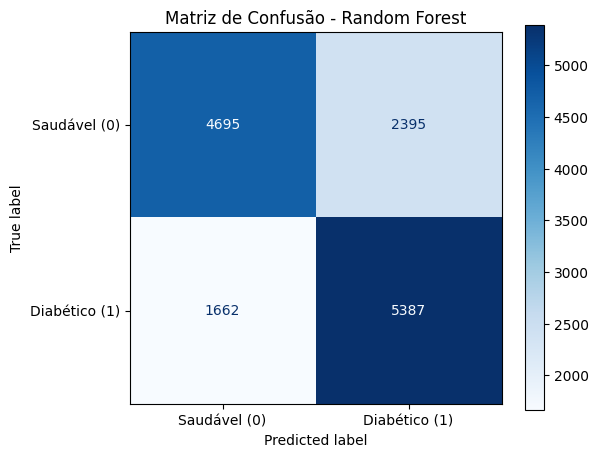

In [4]:
# Cria um DataFrame do Pandas a partir dos resultados coletados
# Ordena os modelos pelo Recall em ordem decrescente e reseta o índice
df_resultados = pd.DataFrame(resultados).sort_values(by="Recall", ascending=False).reset_index(drop=True)

print("🏆 RANKING DOS MODELOS (Ordenado por Recall):")
display(df_resultados) # Exibe o DataFrame de resultados de forma formatada (específico para Jupyter/Colab)

print(f"\n🥇 O modelo vencedor focado na detecção (Recall) foi: {nome_melhor_modelo}")

# Gera a Matriz de Confusão para o modelo que teve o melhor Recall
fig, ax = plt.subplots(figsize=(6, 5)) # Cria uma figura e um eixo para o plot
ConfusionMatrixDisplay.from_estimator(
    modelo_vencedor, # O modelo que foi considerado o melhor
    X_teste,
    Y_teste,
    display_labels=['Saudável (0)', 'Diabético (1)'], # Rótulos para as classes na matriz
    cmap='Blues', # Mapa de cores para a matriz
    ax=ax # O eixo onde a matriz será desenhada
)
plt.title(f'Matriz de Confusão - {nome_melhor_modelo}') # Define o título do gráfico
plt.grid(False) # Remove a grade do gráfico
plt.show() # Exibe o gráfico da matriz de confusão

# 5. EMPACOTAMENTO PARA PRODUÇÃO (Deploy)

In [5]:
print(f"\n📦 Salvando o modelo '{nome_melhor_modelo}' e o Scaler para produção...")

# Cria um dicionário que agrupa o modelo treinado, o scaler de padronização e os nomes das features
# Isso é essencial para que a aplicação web (Streamlit, por exemplo) possa usar o modelo corretamente
pacote_producao = {
    'modelo': modelo_vencedor, # O objeto do modelo de Machine Learning treinado
    'scaler': scaler, # O objeto StandardScaler que foi usado para padronizar os dados
    'features': list(df.drop(columns=['Diabetes_binary']).columns) # Nomes das colunas de características
}

# Define o nome do arquivo onde o pacote será salvo
nome_arquivo_pkl = 'modelo_diabetes_producao.pkl'
# Abre o arquivo no modo de escrita binária ('wb')
with open(nome_arquivo_pkl, 'wb') as arquivo:
    # Serializa o dicionário 'pacote_producao' e o salva no arquivo
    pickle.dump(pacote_producao, arquivo)

print(f"✅ Arquivo '{nome_arquivo_pkl}' gerado com sucesso!")
print("Fim do processamento. O modelo está pronto para ser integrado a uma interface gráfica.")


📦 Salvando o modelo 'Random Forest' e o Scaler para produção...
✅ Arquivo 'modelo_diabetes_producao.pkl' gerado com sucesso!
Fim do processamento. O modelo está pronto para ser integrado a uma interface gráfica.
